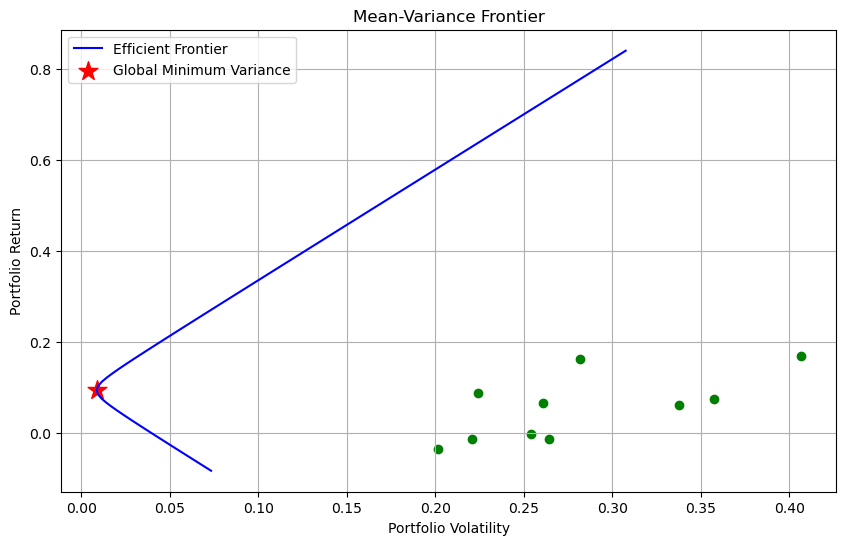


Asset Expected Returns:
Asset 1     0.059671
Asset 2    -0.003826
Asset 3     0.074769
Asset 4     0.162303
Asset 5    -0.013415
Asset 6    -0.013414
Asset 7     0.167921
Asset 8     0.086743
Asset 9    -0.036947
Asset 10    0.064256
dtype: float64

Global Minimum Variance Portfolio:
Return: 0.09287470366090612
Volatility: 0.008673483601495375
Weights:
Asset 1    -0.012588
Asset 2    -0.076511
Asset 3     0.143059
Asset 4     0.394397
Asset 5     0.439250
Asset 6    -0.051496
Asset 7    -0.035606
Asset 8     0.181208
Asset 9    -0.127586
Asset 10    0.145874
dtype: float64


In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Set random seed for reproducibility
np.random.seed(42)

# Generate 10 stocks with random expected returns
n_assets = 10
mu = np.random.normal(0.01, 0.1, n_assets)  # Expected returns around 10%

# Generate a random covariance matrix that is positive definite
A = np.random.randn(n_assets, n_assets)
cov_matrix = np.dot(A, A.T) / n_assets
# Scale the covariance matrix to get reasonable values
cov_matrix = cov_matrix * 0.1

def portfolio_stats(weights, mu, cov_matrix):
    """Calculate portfolio return and volatility"""
    port_return = np.sum(weights * mu)
    port_vol = np.sqrt(np.dot(weights.T, np.dot(cov_matrix, weights)))
    return port_return, port_vol

def get_efficient_portfolio(mu, cov_matrix, target_return=None):
    """Get efficient portfolio weights using closed-form solution"""
    n = len(mu)
    Sigma_inv = np.linalg.inv(cov_matrix)
    e = np.ones(n)
    
    if target_return is None:
        # Global minimum variance portfolio
        lambda2 = 1 / (e.T @ Sigma_inv @ e)
        weights = lambda2 * (Sigma_inv @ e)
    else:
        # Portfolio with target return
        A = np.array([[mu.T @ Sigma_inv @ mu, mu.T @ Sigma_inv @ e],
                     [mu.T @ Sigma_inv @ e, e.T @ Sigma_inv @ e]])
        b = np.array([target_return, 1])
        lambda1, lambda2 = np.linalg.solve(A, b)
        weights = lambda1 * (Sigma_inv @ mu) + lambda2 * (Sigma_inv @ e)
        
    return weights

# Calculate efficient frontier
target_returns = np.linspace(-0.5*max(mu), 5.0*max(mu), 100)
efficient_portfolios = []

for target in target_returns:
    weights = get_efficient_portfolio(mu, cov_matrix, target)
    ret, vol = portfolio_stats(weights, mu, cov_matrix)
    efficient_portfolios.append([ret, vol])

efficient_portfolios = np.array(efficient_portfolios)

# Calculate Global Minimum Variance Portfolio
gmv_weights = get_efficient_portfolio(mu, cov_matrix)
gmv_ret, gmv_vol = portfolio_stats(gmv_weights, mu, cov_matrix)

# Plot efficient frontier
plt.figure(figsize=(10, 6))
plt.plot(efficient_portfolios[:, 1], efficient_portfolios[:, 0], 'b-', label='Efficient Frontier')
plt.scatter(gmv_vol, gmv_ret, color='red', marker='*', s=200, label='Global Minimum Variance')

# Plot individual assets
for i in range(n_assets):
    vol = np.sqrt(cov_matrix[i,i])
    plt.scatter(vol, mu[i], color='green', marker='o')

plt.xlabel('Portfolio Volatility')
plt.ylabel('Portfolio Return')
plt.title('Mean-Variance Frontier')
plt.legend()
plt.grid(True)
plt.savefig('mean_variance_frontier.pdf')
plt.show()

# Print some statistics
print("\nAsset Expected Returns:")
print(pd.Series(mu, index=[f"Asset {i+1}" for i in range(n_assets)]))

print("\nGlobal Minimum Variance Portfolio:")
print("Return:", gmv_ret)
print("Volatility:", gmv_vol)
print("Weights:")
print(pd.Series(gmv_weights, index=[f"Asset {i+1}" for i in range(n_assets)]))


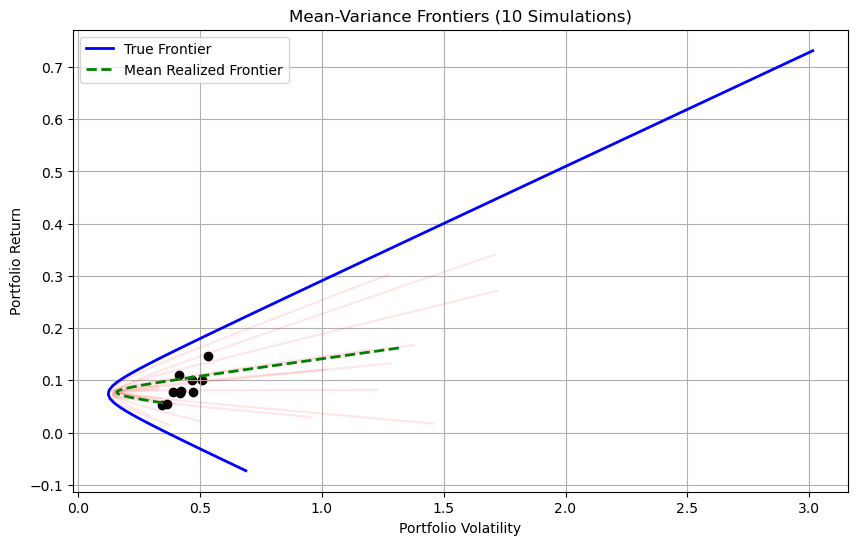


Average Parameter Estimation Errors across Simulations:
Mean absolute error in expected returns: 0.0614 (std: 0.0183)
Mean absolute error in covariances: 0.0333 (std: 0.0098)


In [2]:
# Generate true parameters
n_periods = 24
n_assets = 10
n_simulations = 10  # Number of simulation runs

true_mu = np.random.uniform(0.05, 0.15, n_assets)
true_cov = np.zeros((n_assets, n_assets))
for i in range(n_assets):
    for j in range(i, n_assets):
        if i == j:
            true_cov[i,j] = np.random.uniform(0.1, 0.3)
        else:
            true_cov[i,j] = true_cov[j,i] = np.random.uniform(-0.05, 0.05)

# Arrays to store results across simulations
mae_returns = np.zeros(n_simulations)
mae_cov = np.zeros(n_simulations)
realized_frontiers = []

# Run multiple simulations
for sim in range(n_simulations):
    # Generate historical returns from multivariate normal
    np.random.seed(42 + sim)  # Different seed for each simulation
    returns = np.random.multivariate_normal(true_mu, true_cov, n_periods)
    
    # Estimate parameters from historical data
    est_mu = np.mean(returns, axis=0)
    est_cov = np.cov(returns.T)
    
    # Store estimation errors
    mae_returns[sim] = np.mean(np.abs(true_mu - est_mu))
    mae_cov[sim] = np.mean(np.abs(true_cov - est_cov))
    
    # Calculate realized frontier for this simulation
    target_returns = np.linspace(-0.5*max(true_mu), 5.0*max(true_mu), 100)
    sim_realized_frontier = []
    for target in target_returns:
        weights = get_efficient_portfolio(est_mu, est_cov, target)
        ret, vol = portfolio_stats(weights, true_mu, true_cov)
        sim_realized_frontier.append([ret, vol])
    realized_frontiers.append(np.array(sim_realized_frontier))

# Calculate true frontier (only need to do once)
true_frontier = []
for target in target_returns:
    weights = get_efficient_portfolio(true_mu, true_cov, target)
    ret, vol = portfolio_stats(weights, true_mu, true_cov)
    true_frontier.append([ret, vol])
true_frontier = np.array(true_frontier)

# Plot results
plt.figure(figsize=(10, 6))
plt.plot(true_frontier[:, 1], true_frontier[:, 0], 'b-', linewidth=2, label='True Frontier')

# Plot all realized frontiers with transparency
for frontier in realized_frontiers:
    plt.plot(frontier[:, 1], frontier[:, 0], 'r-', alpha=0.1)

# Plot mean realized frontier
mean_realized_frontier = np.mean(realized_frontiers, axis=0)
plt.plot(mean_realized_frontier[:, 1], mean_realized_frontier[:, 0], 'g--', 
         linewidth=2, label='Mean Realized Frontier')

# Plot individual assets
for i in range(n_assets):
    vol = np.sqrt(true_cov[i,i])
    plt.scatter(vol, true_mu[i], color='black', marker='o')

plt.xlabel('Portfolio Volatility')
plt.ylabel('Portfolio Return')
plt.title(f'Mean-Variance Frontiers ({n_simulations} Simulations)')
plt.legend()
plt.grid(True)
plt.savefig(f'frontier_comparison_{n_periods}_periods.pdf')
plt.show()

# Print average estimation errors across simulations
print("\nAverage Parameter Estimation Errors across Simulations:")
print(f"Mean absolute error in expected returns: {np.mean(mae_returns):.4f} (std: {np.std(mae_returns):.4f})")
print(f"Mean absolute error in covariances: {np.mean(mae_cov):.4f} (std: {np.std(mae_cov):.4f})")


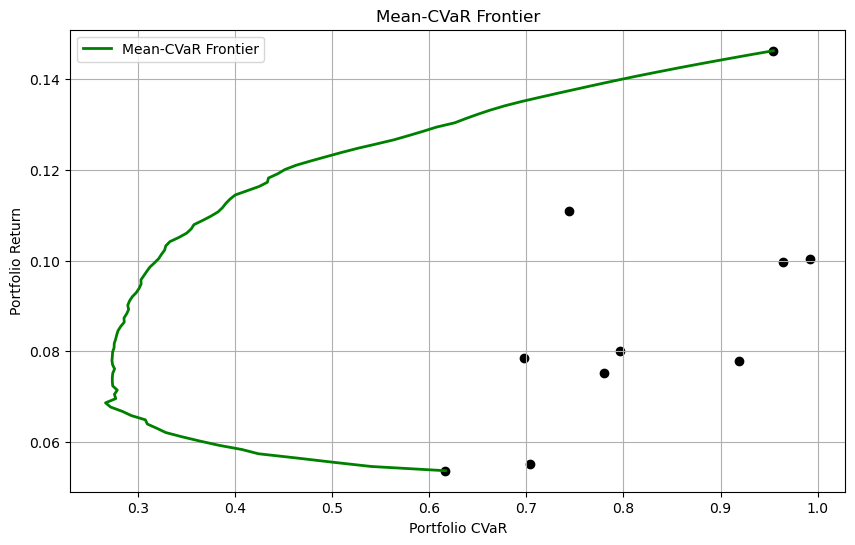

In [3]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import linprog

def simulate_returns(mu, cov, n_scenarios):
    """Simulate returns from multivariate normal distribution"""
    return np.random.multivariate_normal(mu, cov, n_scenarios)

def calculate_cvar(weights, returns, alpha=0.05):
    """Calculate CVaR for a portfolio"""
    portfolio_returns = returns @ weights
    var = np.percentile(portfolio_returns, alpha*100)
    cvar = -np.mean(portfolio_returns[portfolio_returns <= var])
    return cvar

def get_cvar_portfolio(mu, returns, target_return, alpha=0.05):
    """
    Solve mean-CVaR optimization using linear programming
    min CVaR s.t. expected return >= target_return and sum of weights = 1
    """
    n_assets = len(mu)
    n_scenarios = len(returns)
    
    # Variables: [weights (n_assets), VaR (1), auxiliary vars (n_scenarios)]
    n_vars = n_assets + 1 + n_scenarios
    
    # Objective: minimize VaR + (1/((1-alpha)*n_scenarios))*sum(auxiliary vars)
    c = np.zeros(n_vars)
    c[n_assets] = 1  # VaR coefficient
    c[n_assets+1:] = 1/((1-alpha)*n_scenarios)  # auxiliary vars coefficients
    
    # Constraints matrix
    A_ub = np.zeros((n_scenarios, n_vars))
    b_ub = np.zeros(n_scenarios)
    
    # CVaR constraints
    for i in range(n_scenarios):
        A_ub[i, :n_assets] = -returns[i]  # negative returns
        A_ub[i, n_assets] = -1  # VaR
        A_ub[i, n_assets+1+i] = -1  # auxiliary var
    
    # Expected return constraint
    A_eq = np.zeros((2, n_vars))
    A_eq[0, :n_assets] = mu
    A_eq[1, :n_assets] = 1
    b_eq = np.array([target_return, 1])
    
    # Bounds
    bounds = [(0, 1) for _ in range(n_assets)]  # weights between 0 and 1
    bounds.append((None, None))  # VaR unbounded
    bounds.extend([(0, None) for _ in range(n_scenarios)])  # auxiliary vars >= 0
    
    # Solve linear program
    result = linprog(c, A_ub=A_ub, b_ub=b_ub, A_eq=A_eq, b_eq=b_eq, bounds=bounds, method='highs')
    
    if result.success:
        return result.x[:n_assets]
    else:
        return None

# Generate mean-CVaR frontier
n_scenarios = 1000
simulated_returns = simulate_returns(true_mu, true_cov, n_scenarios)

target_returns = np.linspace(np.min(true_mu), np.max(true_mu), 100)
cvar_frontier = []
cvar_mv_frontier = []  # Store mean-variance points for CVaR optimal weights

for target in target_returns:
    weights = get_cvar_portfolio(true_mu, simulated_returns, target)
    if weights is not None:
        portfolio_return = np.dot(weights, true_mu)
        portfolio_cvar = calculate_cvar(weights, simulated_returns)
        cvar_frontier.append([portfolio_return, portfolio_cvar])
        
        # Calculate mean-variance point for CVaR optimal weights
        portfolio_vol = np.sqrt(weights.T @ true_cov @ weights)
        cvar_mv_frontier.append([portfolio_return, portfolio_vol])

cvar_frontier = np.array(cvar_frontier)

# Plot mean-CVaR frontier
plt.figure(figsize=(10, 6))
plt.plot(cvar_frontier[:, 1], cvar_frontier[:, 0], 'g-', linewidth=2, label='Mean-CVaR Frontier')

# Plot individual assets
for i in range(n_assets):
    # Calculate CVaR for single asset portfolio
    single_asset_weights = np.zeros(n_assets)
    single_asset_weights[i] = 1.0
    asset_cvar = calculate_cvar(single_asset_weights, simulated_returns)
    plt.scatter(asset_cvar, true_mu[i], color='black', marker='o')

plt.xlabel('Portfolio CVaR')
plt.ylabel('Portfolio Return')
plt.title('Mean-CVaR Frontier')
plt.legend()
plt.grid(True)
plt.savefig('mean_cvar_frontier.pdf')
plt.show()